[![Labellerr](https://storage.googleapis.com/labellerr-cdn/%200%20Labellerr%20template/notebook.webp)](https://www.labellerr.com)

# **Patient Fall Detection System**

---

[![labellerr](https://img.shields.io/badge/Labellerr-BLOG-black.svg)](https://www.labellerr.com/blog/<BLOG_NAME>)
[![Youtube](https://img.shields.io/badge/Labellerr-YouTube-b31b1b.svg)](https://www.youtube.com/@Labellerr)
[![Github](https://img.shields.io/badge/Labellerr-GitHub-green.svg)](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)



## Project Overview  
This project is built on three core pillars: **Object Segmentation, Spatial Geofencing, and Actionable Alerts**.

### Custom Segmentation  
Instead of traditional bounding boxes, the system uses **instance segmentation** to identify the exact pixels belonging to a patient.  
This is critical in hospital environments where beds, blankets, and medical equipment often overlap.

---

### Geofencing (Polygon Zones)  
A custom **7-point polygon** defines a "Safe Zone" around the bed, accounting for camera perspective.  
- Inside the polygon → Safe Zone (bed area)  
- Outside the polygon → Fall Zone (risk area)  

---

### Mathematical Decision Making  
Using the **Shapely** library, the system performs real-time **Point-in-Polygon** checks.  
It calculates the **centroid (center)** of the patient’s mask and instantly triggers an alert when this point exits the defined safe zone.

---

## Real-World Applications  

### Healthcare & Elderly Care  
Detects bed-exit events to prevent patient falls and assist in monitoring high-risk individuals.

### Smart Home Security  
Tracks movement in sensitive zones (e.g., stairs, pools) and sends alerts for safety or intrusion.


---

## Annotate your Custom dataset using Labellerr

 ***1. Visit the [Labellerr](https://www.labellerr.com/?utm_source=githubY&utm_medium=social&utm_campaign=github_clicks) website and click **“Sign Up”**.*** 

 ***2. After signing in, create your workspace by entering a unique name.***

 ***3. Navigate to your workspace’s API keys page (e.g., `https://<your-workspace>.labellerr.com/workspace/api-keys`) to generate your **API Key** and **API Secret**.***

 ***4. Store the credentials securely, and then use them to initialise the SDK or API client with `api_key`, `api_secret`.*** 



## Import Libraries

This section imports all the required libraries used throughout the project for computer vision, visualization, deep learning, and structured coding.


In [6]:
!git clone https://github.com/Labellerr/yolo_finetune_utils.git

Cloning into 'yolo_finetune_utils'...


In [2]:
!pip install ultralytics opencv-python matplotlib cv2

ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for cv2


## 🎞️ Random Frame Extraction from Video

Extracts a fixed number of high-quality frames from one or more videos to create an image dataset for annotation and training.

### 🔹 Purpose
- Convert raw manufacturing videos into individual image frames  
- Perform random sampling to avoid frame bias  
- Prepare data for annotation and YOLO training  


In [10]:
from yolo_finetune_utils.frame_extractor import extract_random_frames

extract_random_frames(
    paths=['download.mp4'],
    total_images=40,
    out_dir="datasetFrames",
    jpg_quality=100,
    seed=42
)

[✓] Extracted 40 frames to folder: datasetFrames


## 📥 Download Annotations from Labellerr

After completing data labeling on the **Labellerr** platform, export the annotations in **COCO JSON format**.

Download the COCO JSON file from the Labellerr website and upload it into this project workspace to use it for further dataset preparation and training.

This COCO JSON file will be used in the next steps for:
- Frame–annotation alignment
- COCO → YOLO format conversion
- Model training and evaluation


# COCO to YOLO Format Conversion

Converts COCO-style segmentation annotations to YOLO segmentation dataset format.  
- Requires: `annotation.json` and images in `frames_output` directory.
- Output: Generated YOLO dataset folder.
- Parameters: allows train/val split, shuffling, and verbose mode.


In [12]:
from yolo_finetune_utils.coco_yolo_converter.seg_converter import coco_to_yolo_converter

coco_to_yolo_converter(
    json_path="4162fc95-f607-4b15-83c2-0f78d6b6f219.json",
    images_dir="dataset_Frames",
    output_dir="yolos_Dataset",
    use_split=True,
    train_ratio=0.9,
    val_ratio=0.1,
    test_ratio=0,
    shuffle=True,
    verbose=True
)

Conversion complete. Stats: {'train': 35, 'val': 4, 'test': 0}


{'stats': {'train': 35, 'val': 4, 'test': 0}, 'output_dir': 'yolos_Dataset'}

# Load and Train YOLO Segmentation Model

Loads the YOLO segmentation model and trains it using the converted YOLO dataset.
- Data: Path to YOLO-style `data.yaml`
- Parameters: epochs, image size, batch size, device, dataloader workers, experiment name.


In [ ]:
# Initialize the Extra Large model
model = YOLO('yolo11n-seg.pt') 

results = model.train(
    data='/kaggle/working/mdata.yaml',
    epochs=150,
    imgsz=640,
    batch=16,
    project='/kaggle/working/newpatient',
    name='train_run_7',
    device=0,
    
    # --- AUGMENTATION HAPPENS HERE ---
    degrees=15.0,    # Randomly rotates images up to +/- 15 degrees
    fliplr=0.5,      # 50% chance to flip left-right
    flipud=0.5       # 50% chance to flip upside-down
)

# YOLOv11 Instance Segmentation: Single Frame Inference
 
This script performs **single-frame inference** using a custom-trained YOLOv11 segmentation model.  
It extracts a specific frame from a video and applies instance segmentation to verify the predictions.


0: 384x640 1 Patient, 303.3ms
Speed: 14.9ms preprocess, 303.3ms inference, 32.5ms postprocess per image at shape (1, 3, 384, 640)


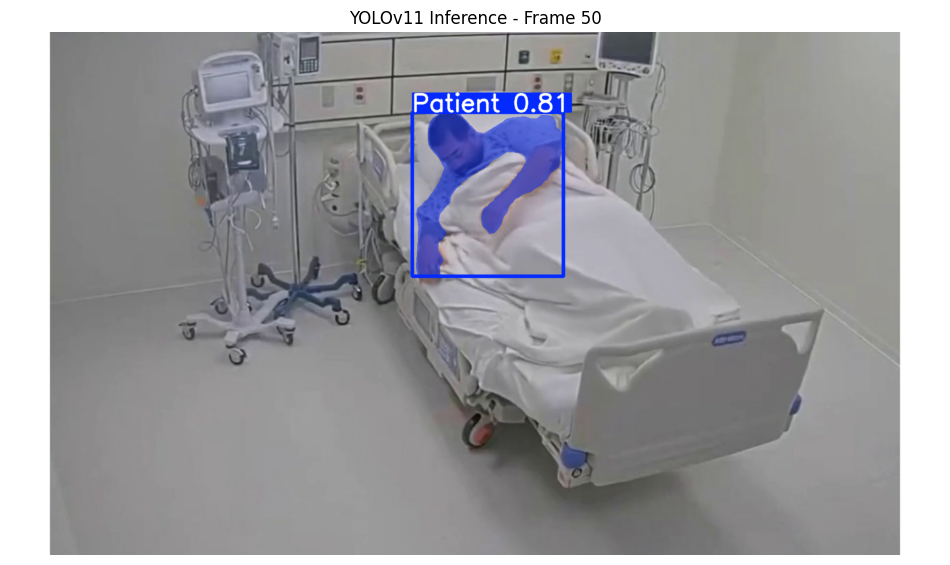

In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load your custom trained waste model
model = YOLO('best (15).pt') 

# 2. Path to your video file
video_path = 'download.mp4'
cap = cv2.VideoCapture(video_path)

# 3. Jump to the 700th frame
frame_no = 50
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_no)
success, frame = cap.read()

if success:
    # 4. Run inference
    results = model.predict(
        source=frame, 
        conf=0.7,
        retina_masks=True,
        show_boxes=False,
        show_labels=True
    )

    # 5. Get the annotated frame (OpenCV uses BGR)
    annotated_frame = results[0].plot()

    # 6. Convert BGR to RGB for Matplotlib (OpenCV colors are swapped)
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)

    # 7. Display directly in VS Code output
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_frame_rgb)
    plt.axis('off')  # Hide the X and Y axis numbers
    plt.title(f"YOLOv11 Inference - Frame {frame_no}")
    plt.show()
    
else:
    print(f"Error: Frame {frame_no} not found.")

cap.release()

# Inference & Tracking Engine

## Overview  
This code serves as the **inference and tracking engine**, applying the custom-trained model to real-world video footage.  
It ensures consistent detection, efficient processing, and high-quality segmentation output.

---

## Code Summary  

### Model Initialization  
Loads the custom-trained weights file (`best.pt`) to detect the **Patient** class accurately.

---

### Intelligent Tracking  
Uses `model.track(...)` to assign a **unique ID** to the patient.  
This ensures continuous tracking across frames, even during movement or partial occlusion.

---

### Memory Efficiency  
Enables `stream=True` to process the video as a **generator (frame-by-frame)**.  
This allows handling long videos efficiently without causing memory crashes, especially in environments like Kaggle.

---

### High-Fidelity Output  
Uses `retina_masks=True` to generate **smooth, pixel-accurate segmentation masks**.  
This avoids low-resolution or blocky outputs, ensuring precise visual representation.

---

In [ ]:
from ultralytics import YOLO

# 1. Load your newly trained custom model
# Make sure "best.pt" is in the same directory, or provide the full path
model = YOLO("/kaggle/working/newpatient/train_run_7/weights/best.pt") 

video_path = "/kaggle/input/datasets/aaryanaggarwal5040/patient-fall/download.mp4" # Update this to your actual video file name

print(f"Starting inference on {video_path}...")
results = model.track(
    source=video_path,
    save=True, 
    conf=0.3,
    show_boxes=True,    # Keep this False to hide the rectangles
    show_labels=True,    # Keep this True to see the names
    show_conf=False,
    retina_masks=True,
    stream=True,
    # --- ADD THIS TO SHRINK THE TEXT ---
    line_width=2         # This will make the font significantly smaller and thinner
)

# 3. Execute the video processing loop
# Because stream=True creates a generator, we must iterate through it to process the video
for frame_result in results:
    pass 

print("\nInference complete!")
print("Look for your newly generated video inside the 'runs/segment/predict/' folder.")

# Zone Calibration Utility

## Overview  
This module is used to define the **geofencing boundary** for fall detection.  
It provides an interactive way to capture precise coordinates from a video frame and convert them into usable polygon data.

---

## Key Functional Steps  

### Frame Grabber  
Extracts a specific frame (e.g., the 5th frame) from the video to serve as a **static reference image** for calibration.

---

### Interactive Input  
Uses an OpenCV mouse callback to capture exact pixel coordinates `(x, y)` based on user clicks.

---

### Live Preview  
Draws a dynamic **green polygon** as points are selected, allowing real-time visual confirmation of the defined boundary.

---

### Coordinate Export  
Generates a `ZONE_POINTS` list containing all selected coordinates.  
This list is then used in the main script to define the **mathematical boundary** for fall detection.


In [1]:
import cv2
import numpy as np

# 1. Setup paths
video_path = "download.mp4" # Update this!
points = []

# 2. Callback function to handle mouse clicks
def draw_polygon(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        points.append((x, y))
        print(f"Added point: ({x}, {y})")

# 3. Extract the 5th frame
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 4)
success, frame = cap.read()
cap.release()

if not success:
    print("Error: Could not open video or find the 5th frame.")
else:
    # 4. Create a named window and set the mouse callback
    cv2.namedWindow("Mark Bed Perimeter")
    cv2.setMouseCallback("Mark Bed Perimeter", draw_polygon)

    print("--- INSTRUCTIONS ---")
    print("1. Click the corners of the bed perimeter.")
    print("2. Press 'q' or 'Esc' to finish and save.")
    print("3. Press 'r' to reset points.")

    while True:
        # Create a copy so we don't draw permanently on the original frame
        temp_frame = frame.copy()
        
        # Draw the points and lines
        if len(points) > 0:
            for pt in points:
                cv2.circle(temp_frame, pt, 5, (0, 0, 255), -1)
            
            if len(points) > 1:
                pts_array = np.array(points, np.int32).reshape((-1, 1, 2))
                cv2.polylines(temp_frame, [pts_array], isClosed=True, color=(0, 255, 0), thickness=2)

        cv2.imshow("Mark Bed Perimeter", temp_frame)
        
        key = cv2.waitKey(1) & 0xFF
        if key == ord('q') or key == 27: # 'q' or Esc
            break
        elif key == ord('r'): # Reset
            points = []
            print("Points cleared.")

    cv2.destroyAllWindows()

    # 5. Output the final coordinates
    print("\n--- FINAL COORDINATES ---")
    print(f"ZONE_POINTS = {points}")

--- INSTRUCTIONS ---
1. Click the corners of the bed perimeter.
2. Press 'q' or 'Esc' to finish and save.
3. Press 'r' to reset points.
Added point: (738, 306)
Added point: (1097, 756)
Added point: (1537, 613)
Added point: (1149, 247)
Added point: (1130, 133)
Added point: (722, 168)

--- FINAL COORDINATES ---
ZONE_POINTS = [(738, 306), (1097, 756), (1537, 613), (1149, 247), (1130, 133), (722, 168)]


# Core Intelligence Module

## Overview  
This module is the **core intelligence layer** of the project.  
It combines the custom-trained AI model with mathematical logic to detect **dangerous events in real time**, such as patient falls.

---

## Code Summary  

### Spatial Geofencing  
Uses a custom **7-point polygon** to define a "Safe Zone" around the bed.  
Any movement outside this boundary is treated as a potential risk event.

---

### Full Shape Rendering  
Displays the complete **segmentation mask** (cyan outline and fill) instead of simple bounding boxes.  
This ensures the system tracks the **entire body** accurately.

---

### Point-in-Polygon Logic  
Calculates the patient’s **centroid (center of mass)** and checks whether it lies inside the defined polygon.  
An alert is triggered instantly when this point exits the safe zone.

---

### Automated Alerting  
Overlays a high-visibility **red alert banner** on the video when a fall is detected.  
This creates a clear and immediate visual indicator of the incident.

---

## Technical Goal  

To deliver a reliable **real-time fall detection system** that combines computer vision with geometric reasoning for accurate and actionable alerts.

---

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from shapely.geometry import Point, Polygon

# 1. Your Custom Zone (7-point perimeter)
ZONE_POINTS = [(723, 298), (719, 138), (1146, 106), (1149, 247), (1546, 596), (1198, 657), (1152, 776)]
poly_zone = Polygon(ZONE_POINTS)

# 2. Load YOUR Custom Model 
model_path = "/kaggle/working/newpatient/train_run_7/weights/best.pt"
model = YOLO(model_path) 

# 3. Setup Video Paths
video_path = "/kaggle/input/datasets/aaryanaggarwal5040/patient-fall/download.mp4"
output_path = "/kaggle/working/custom_segmentation_alert.mp4"

cap = cv2.VideoCapture(video_path)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

# Setup Video Writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print(f"Starting inference with full segmentation display...")

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Run tracking
    results = model.track(frame, persist=True, verbose=False, conf=0.3)

    # Visual: Draw the Bed Perimeter (Green)
    bed_pts = np.array(ZONE_POINTS, np.int32).reshape((-1, 1, 2))
    cv2.polylines(frame, [bed_pts], isClosed=True, color=(0, 255, 0), thickness=3)

    fall_detected = False

    if results[0].masks is not None:
        for mask_coords in results[0].masks.xy:
            # --- NEW: DRAW COMPLETE SEGMENTATION MASK ---
            # Convert mask coordinates to integer format for OpenCV
            patient_mask_pts = np.array(mask_coords, np.int32).reshape((-1, 1, 2))
            
            # Draw the patient's polygon segmentation (Cyan color)
            cv2.polylines(frame, [patient_mask_pts], isClosed=True, color=(255, 255, 0), thickness=2)
            
            # (Optional) Add a semi-transparent fill to the segmentation
            overlay = frame.copy()
            cv2.fillPoly(overlay, [patient_mask_pts], (255, 255, 0))
            cv2.addWeighted(overlay, 0.3, frame, 0.7, 0, frame)

            # --- LOGIC: Still use the center for fall detection stability ---
            center_x = int(np.mean(mask_coords[:, 0]))
            center_y = int(np.mean(mask_coords[:, 1]))
            patient_center = Point(center_x, center_y)

            if not poly_zone.contains(patient_center):
                fall_detected = True

    # 4. Display the ALERT
    if fall_detected:
        cv2.rectangle(frame, (20, 20), (580, 100), (0, 0, 255), -1)
        cv2.putText(
            frame, "ALERT!!! PATIENT FALL", (40, 75),
            cv2.FONT_HERSHEY_SIMPLEX, 1.4, (255, 255, 255), 4
        )

    out.write(frame)

cap.release()
out.release()
print(f"Done! Check Output folder for: {output_path}")

---

## 👨‍💻 About Labellerr's Hands-On Learning in Computer Vision

Thank you for exploring this **Labellerr Hands-On Computer Vision Cookbook**! We hope this notebook helped you learn, prototype, and accelerate your vision projects.  
Labellerr provides ready-to-run Jupyter/Colab notebooks for the latest models and real-world use cases in computer vision, AI agents, and data annotation.

---
## 🧑‍🔬 Check Our Popular Youtube Videos

Whether you're a beginner or a practitioner, our hands-on training videos are perfect for learning custom model building, computer vision techniques, and applied AI:

- [How to Fine-Tune YOLO on Custom Dataset](https://www.youtube.com/watch?v=pBLWOe01QXU)  
  Step-by-step guide to fine-tuning YOLO for real-world use—environment setup, annotation, training, validation, and inference.
- [Build a Real-Time Intrusion Detection System with YOLO](https://www.youtube.com/watch?v=kwQeokYDVcE)  
  Create an AI-powered system to detect intruders in real time using YOLO and computer vision.
- [Finding Athlete Speed Using YOLO](https://www.youtube.com/watch?v=txW0CQe_pw0)  
  Estimate real-time speed of athletes for sports analytics.
- [Object Counting Using AI](https://www.youtube.com/watch?v=smsjBBQcIUQ)  
  Learn dataset curation, annotation, and training for robust object counting AI applications.
---

## 🎦 Popular Labellerr YouTube Videos

Level up your skills and see video walkthroughs of these tools and notebooks on the  
[Labellerr YouTube Channel](https://www.youtube.com/@Labellerr/videos):

- [How I Fixed My Biggest Annotation Nightmare with Labellerr](https://www.youtube.com/watch?v=hlcFdiuz_HI) – Solving complex annotation for ML engineers.
- [Explore Your Dataset with Labellerr's AI](https://www.youtube.com/watch?v=LdbRXYWVyN0) – Auto-tagging, object counting, image descriptions, and dataset exploration.
- [Boost AI Image Annotation 10X with Labellerr's CLIP Mode](https://www.youtube.com/watch?v=pY_o4EvYMz8) – Refine annotations with precision using CLIP mode.
- [Boost Data Annotation Accuracy and Efficiency with Active Learning](https://www.youtube.com/watch?v=lAYu-ewIhTE) – Speed up your annotation workflow using Active Learning.

> 👉 **Subscribe** for Labellerr's deep learning, annotation, and AI tutorials, or watch videos directly alongside notebooks!

---

## 🤝 Stay Connected

- **Website:** [https://www.labellerr.com/](https://www.labellerr.com/)
- **Blog:** [https://www.labellerr.com/blog/](https://www.labellerr.com/blog/)
- **GitHub:** [Labellerr/Hands-On-Learning-in-Computer-Vision](https://github.com/Labellerr/Hands-On-Learning-in-Computer-Vision)
- **LinkedIn:** [Labellerr](https://in.linkedin.com/company/labellerr)
- **Twitter/X:** [@Labellerr1](https://x.com/Labellerr1)

*Happy learning and building with Labellerr!*
